In [2]:
import numpy as np
import matplotlib.pyplot as plt
import importlib
import final_forward_attenuation
importlib.reload(final_forward_attenuation)
from final_forward_attenuation import run_simulation, default_species, convert_atm, txt_to_npy, convert_vmr, plot_npy, plot_histogram, downsample, count_lines_by_index

H2O

/teamspace/studios/this_studio/Stand-off
Using species: ['H2O']
DEBUG: H2O iso=1 qfile=TIPS/H2O/q1.txt exists=True
DEBUG: H2O iso=2 qfile=TIPS/H2O/q2.txt exists=True
DEBUG: H2O iso=3 qfile=TIPS/H2O/q3.txt exists=True
DEBUG: H2O iso=4 qfile=TIPS/H2O/q4.txt exists=True
DEBUG: H2O iso=5 qfile=TIPS/H2O/q5.txt exists=True
DEBUG: H2O iso=6 qfile=TIPS/H2O/q6.txt exists=True
DEBUG: H2O iso=7 qfile=TIPS/H2O/q129.txt exists=True


/teamspace/studios/this_studio/Stand-off/final_forward_attenuation.py:252: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(qfile, header=None, delim_whitespace=True, comment='#')
/teamspace/studios/this_studio/Stand-off/final_forward_attenuation.py:252: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(qfile, header=None, delim_whitespace=True, comment='#')
/teamspace/studios/this_studio/Stand-off/final_forward_attenuation.py:252: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(qfile, header=None, delim_whitespace=True, comment='#')
/teamspace/studios/this_studio/Stand-off/final_forward_attenuation.py:252: FutureWarning: The 'delim_whitespace' keyword in 

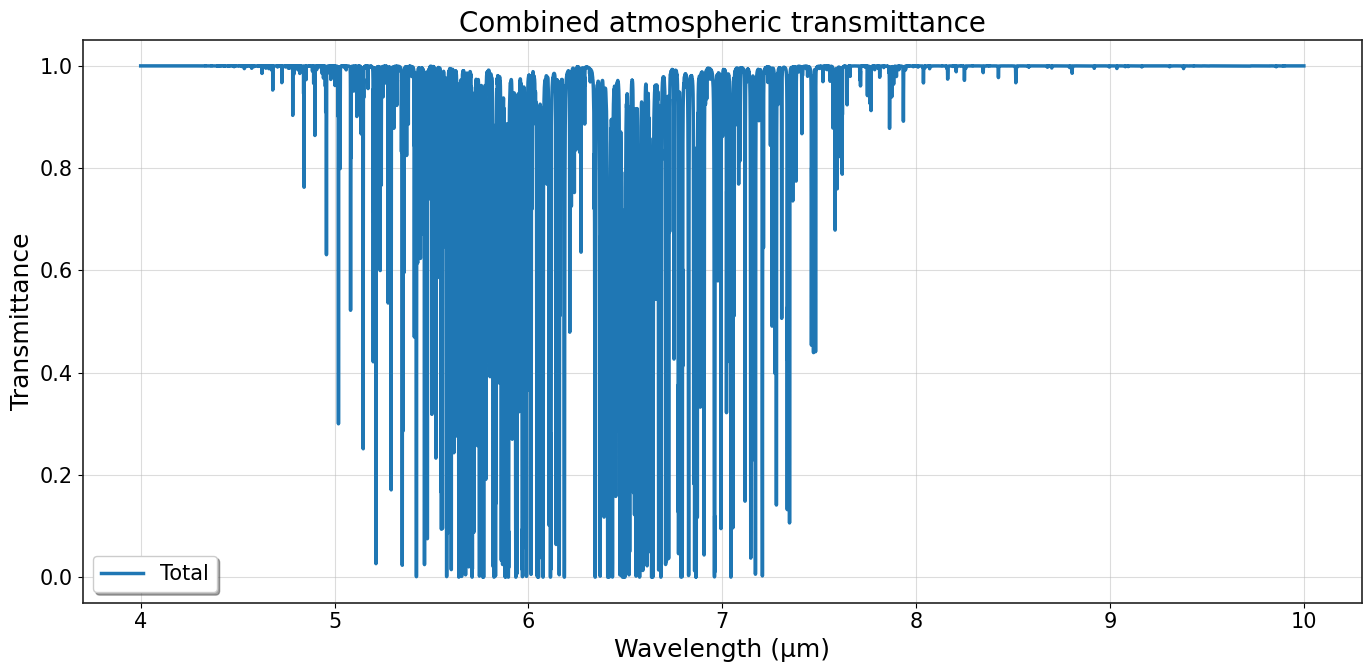

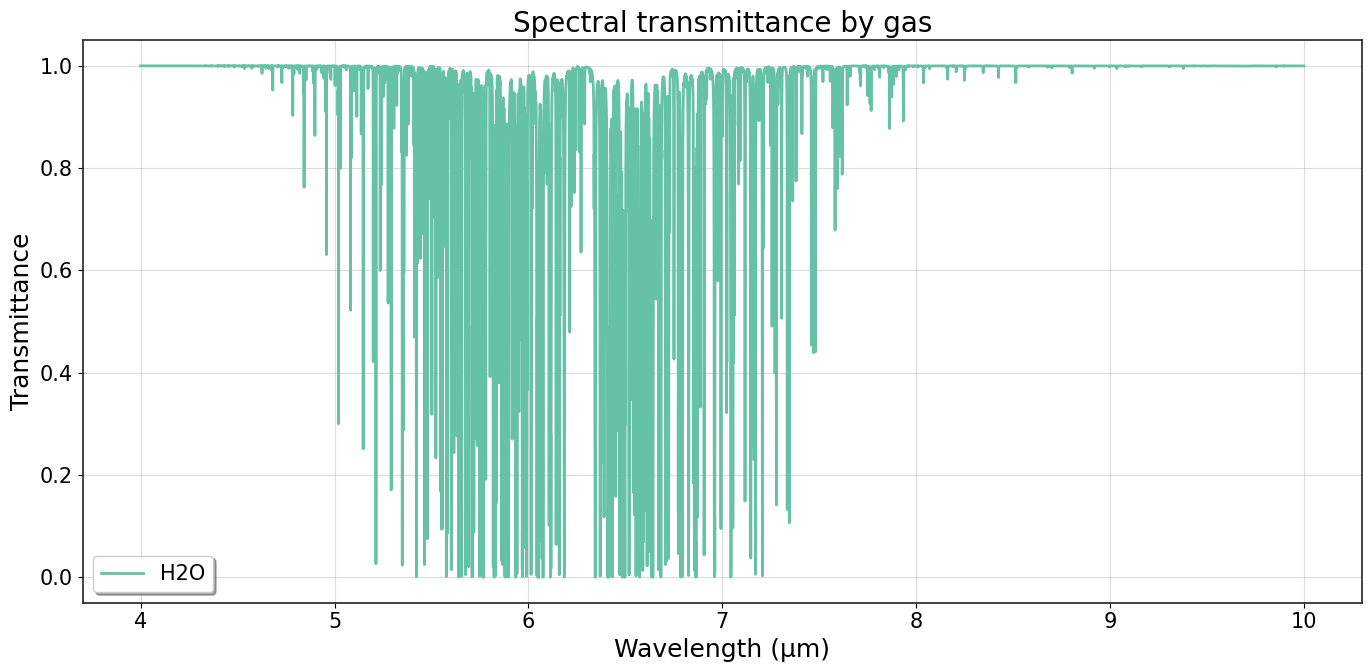

In [2]:
Ptotal = convert_atm(1013, "mbar")
T = 288.2

sp = default_species()
for s in sp:
     if s.name == 'H2O': s.Pmol = 0.0077480878361707375 
     else: s.Pmol = 0.0
    

import os
print(os.getcwd())

res = run_simulation(
    species=sp,
    parfile='PARS/ALL.par',
    nu_min=1000, nu_max=2500, dnu=0.0001,
    tileW=20.0, guard=5.0,
    temp_K=T, L_m=1.0, pres=Ptotal,
    delta_um=0.0001,
    save_csv=True, outdir='OUT', make_plots=True, 
    att=False, transmission_npy_name='Simulated_Standard_H2O_4-10_1m.npy',
    use_all_isotopologues=True, species_to_use=['H2O']

)

lambda_um = res['lambda_centers']
Tprod = res['T_prod_samp']
Tco2  = res['T_each_samp'][0]

In [4]:
gt = np.load("GT_PROFE/Transmittance_Standard_H2O_4-10_1m.npy")
sim = np.load("SIMULATED/Simulated_Standard_H2O_4-10_1m.npy")  
output = "SIMULATED/Transmittance_Standard_H2O_4-10_1m__downsampled_to_Prueba_Isotopologos.npy"
downsample(sim, gt, output)

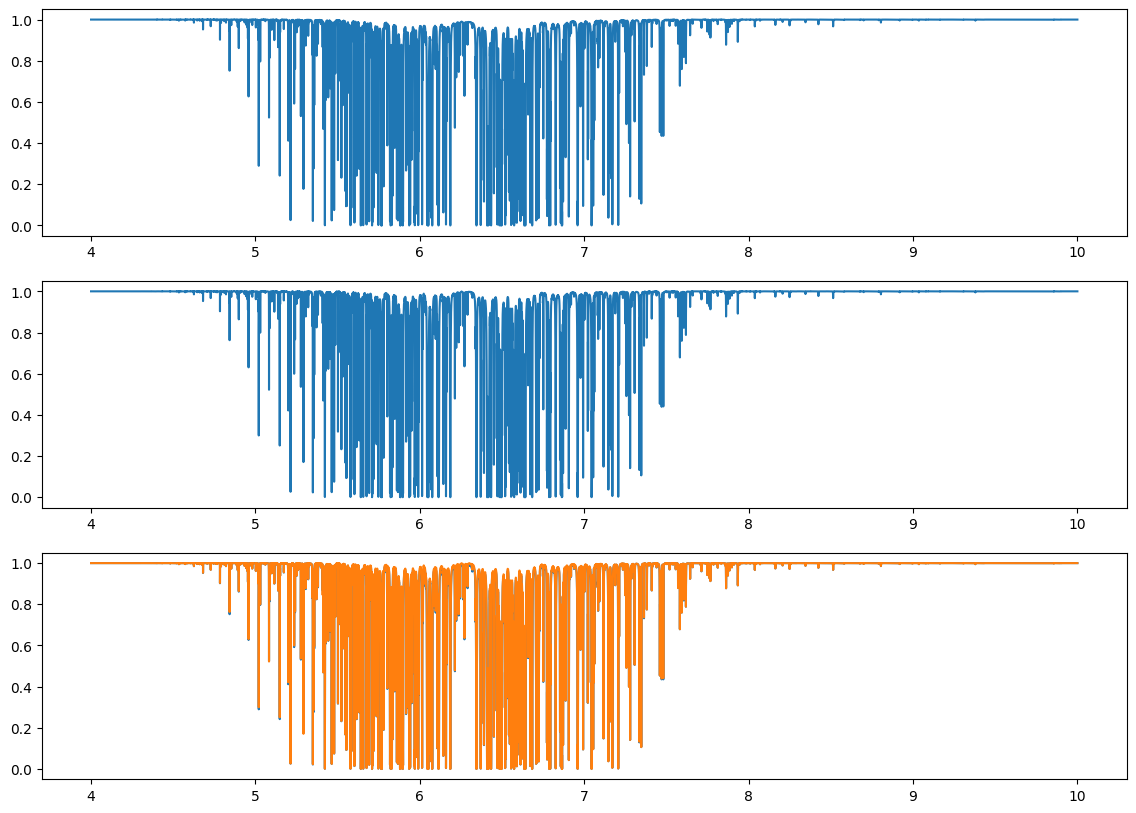

In [2]:
gt = np.load("SIMULATED/Transmittance_Standard_H2O_4-10_1m__downsampled_to_Prueba_Isotopologos.npy")
sim = np.load("SIMULATED/Simulated_Standard_H2O_4-10_1m.npy")  
plt.figure(figsize=(14, 10))
plt.subplot(311)
plt.plot(gt[0], gt[1])
plt.subplot(312)
plt.plot(sim[0], sim[1])
plt.subplot(313)
plt.plot(gt[0], gt[1])
plt.plot(sim[0], sim[1])

MAE: 0.0017445823377946316


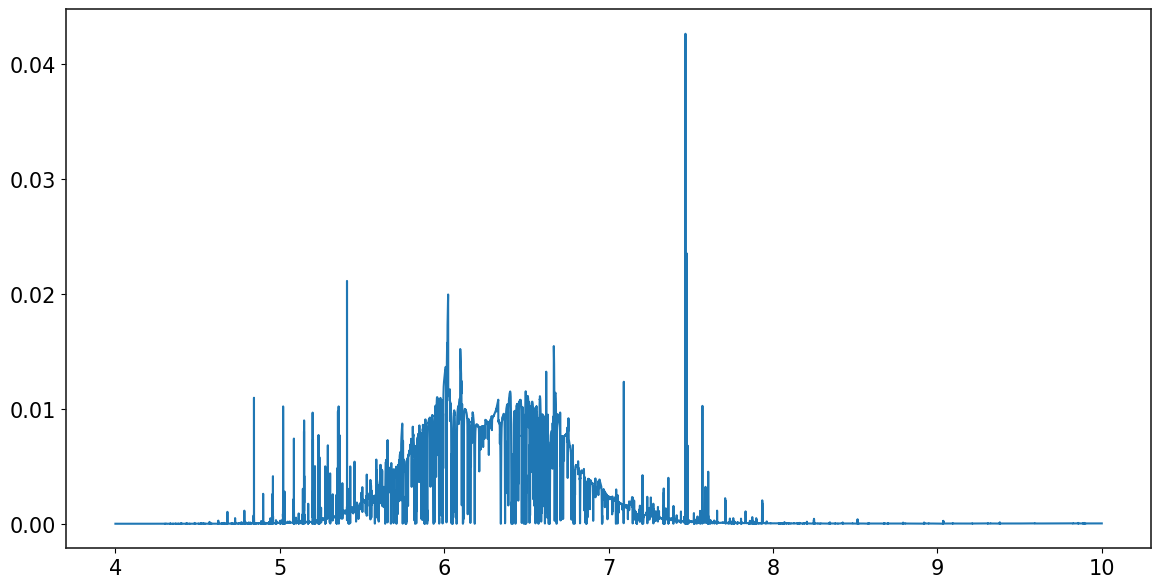

In [6]:
residual = np.abs((gt[1]-sim[1]))
mae = np.mean(np.abs(gt[1]-sim[1]))
plt.figure(figsize=(14,7))
plt.plot(gt[0], residual)
print("MAE:", mae)

CO2

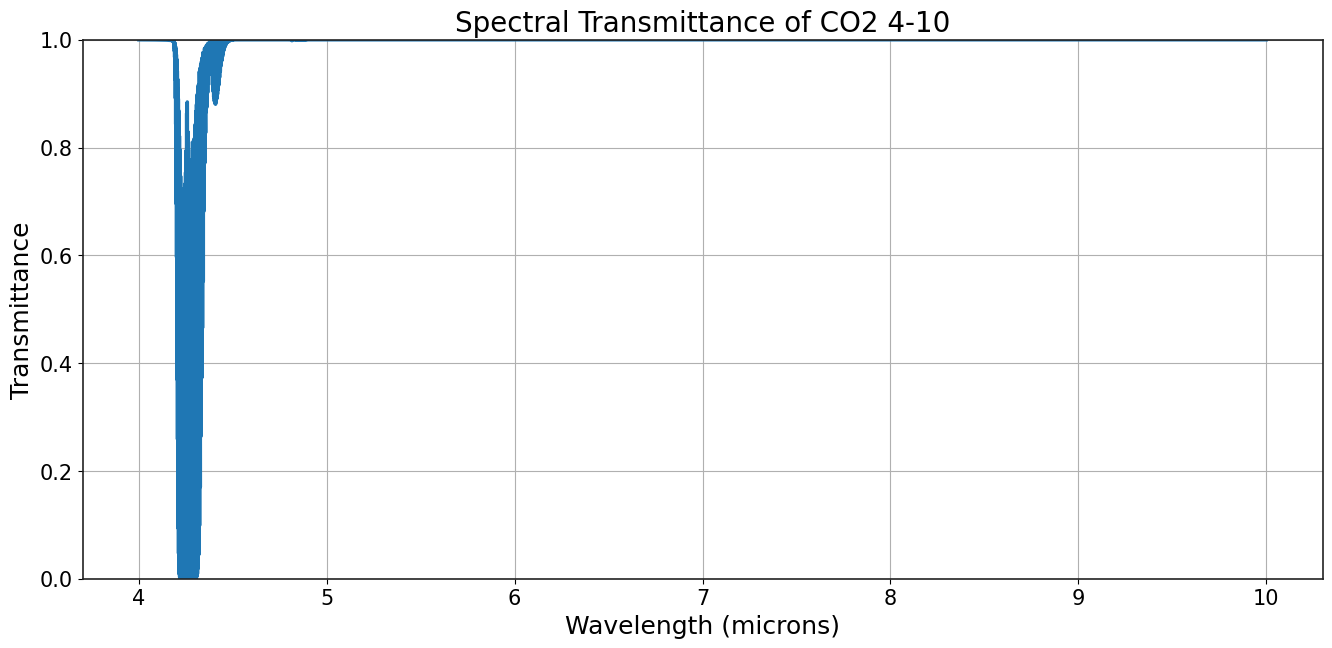

In [19]:
'''ground truth'''
sign = np.load("GT_PROFE/Transmittance_Standard_CO2_4-10_1m.npy")
plot_npy(sign[0], sign[1], name='CO2 4-10')

/teamspace/studios/this_studio/Stand-off
Using species: ['CO2']
DEBUG: CO2 iso=1 qfile=TIPS/CO2/q7.txt exists=True
DEBUG: CO2 iso=2 qfile=TIPS/CO2/q8.txt exists=True
DEBUG: CO2 iso=3 qfile=TIPS/CO2/q9.txt exists=True
DEBUG: CO2 iso=4 qfile=TIPS/CO2/q10.txt exists=True
DEBUG: CO2 iso=5 qfile=TIPS/CO2/q11.txt exists=True
DEBUG: CO2 iso=6 qfile=TIPS/CO2/q12.txt exists=True
DEBUG: CO2 iso=7 qfile=TIPS/CO2/q13.txt exists=True
DEBUG: CO2 iso=8 qfile=TIPS/CO2/q14.txt exists=True
DEBUG: CO2 iso=9 qfile=TIPS/CO2/q15.txt exists=True
DEBUG: CO2 iso=10 qfile=TIPS/CO2/q120.txt exists=True
DEBUG: CO2 iso=A qfile=TIPS/CO2/q121.txt exists=True
DEBUG: CO2 iso=B qfile=TIPS/CO2/q122.txt exists=True


/teamspace/studios/this_studio/Stand-off/final_forward_attenuation.py:252: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(qfile, header=None, delim_whitespace=True, comment='#')
/teamspace/studios/this_studio/Stand-off/final_forward_attenuation.py:252: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(qfile, header=None, delim_whitespace=True, comment='#')
/teamspace/studios/this_studio/Stand-off/final_forward_attenuation.py:252: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(qfile, header=None, delim_whitespace=True, comment='#')
/teamspace/studios/this_studio/Stand-off/final_forward_attenuation.py:252: FutureWarning: The 'delim_whitespace' keyword in 

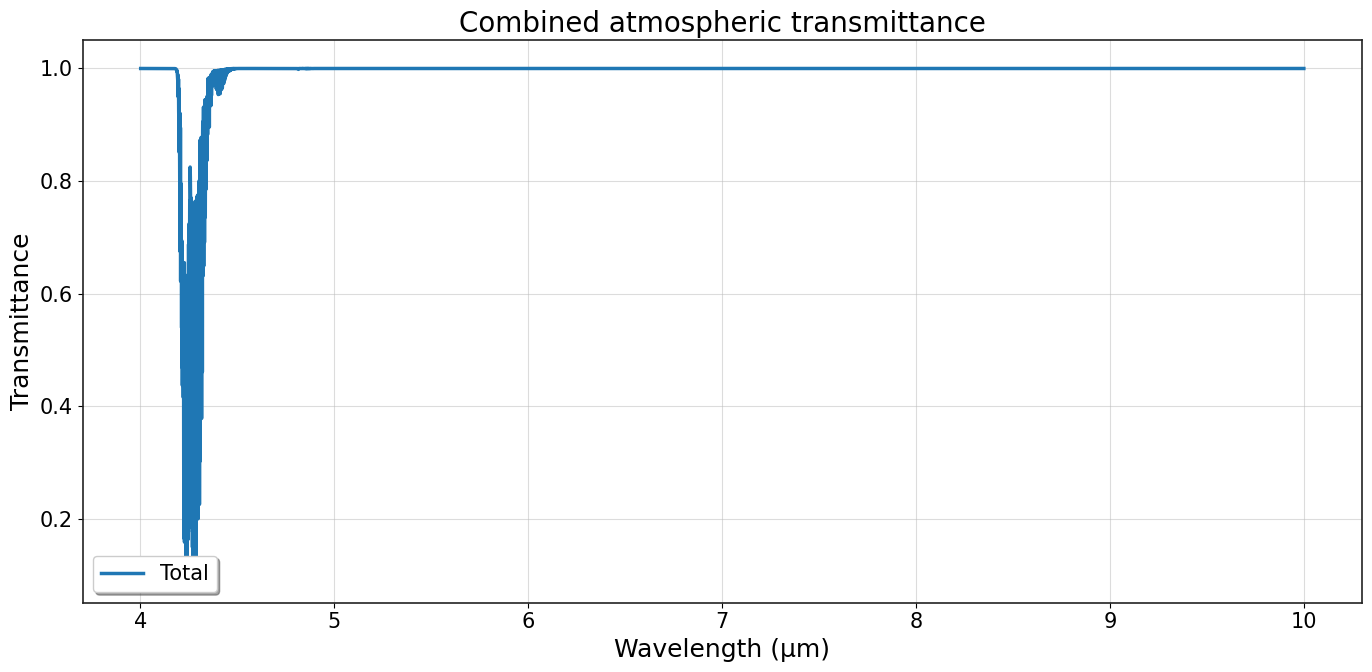

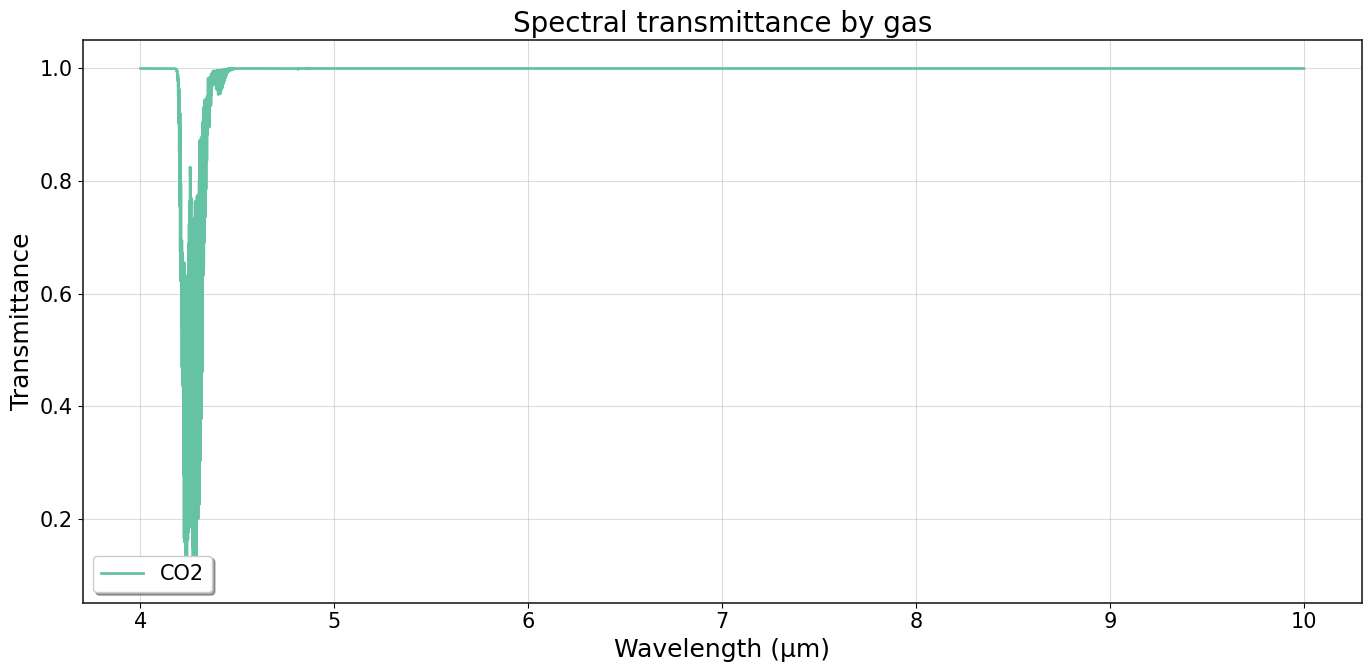

In [20]:
'''simulated'''
Ptotal = convert_atm(1013, "mbar")
T = 288.2

sp = default_species()
for s in sp:
     if s.name == 'CO2': s.Pmol = 0.0003299185788304959
     else: s.Pmol = 0.0
    

import os
print(os.getcwd())

res = run_simulation(
    species=sp,
    parfile='PARS/ALL.par',
    nu_min=1000, nu_max=2500, dnu=0.001,
    tileW=20.0, guard=5.0,
    temp_K=T, L_m=1.0, pres=Ptotal,
    delta_um=0.001,
    save_csv=True, outdir='OUT', make_plots=True, 
    att=False, transmission_npy_name='Simulated_Standard_CO2_4-10_1m.npy',
    use_all_isotopologues=True, species_to_use=['CO2']

)

lambda_um = res['lambda_centers']
Tprod = res['T_prod_samp']
Tco2  = res['T_each_samp'][0]

In [21]:
simulated = np.load("SIMULATED/Simulated_Standard_CO2_4-10_1m.npy")
gt = np.load("GT_PROFE/Transmittance_Standard_CO2_4-10_1m.npy")
output = "SIMULATED/Transmittance_Standard_CO2_4-10_1m__downsampled_to_Simulated_Standard_CO2_4-10_1m.npy"
downsample(simulated, gt, output)

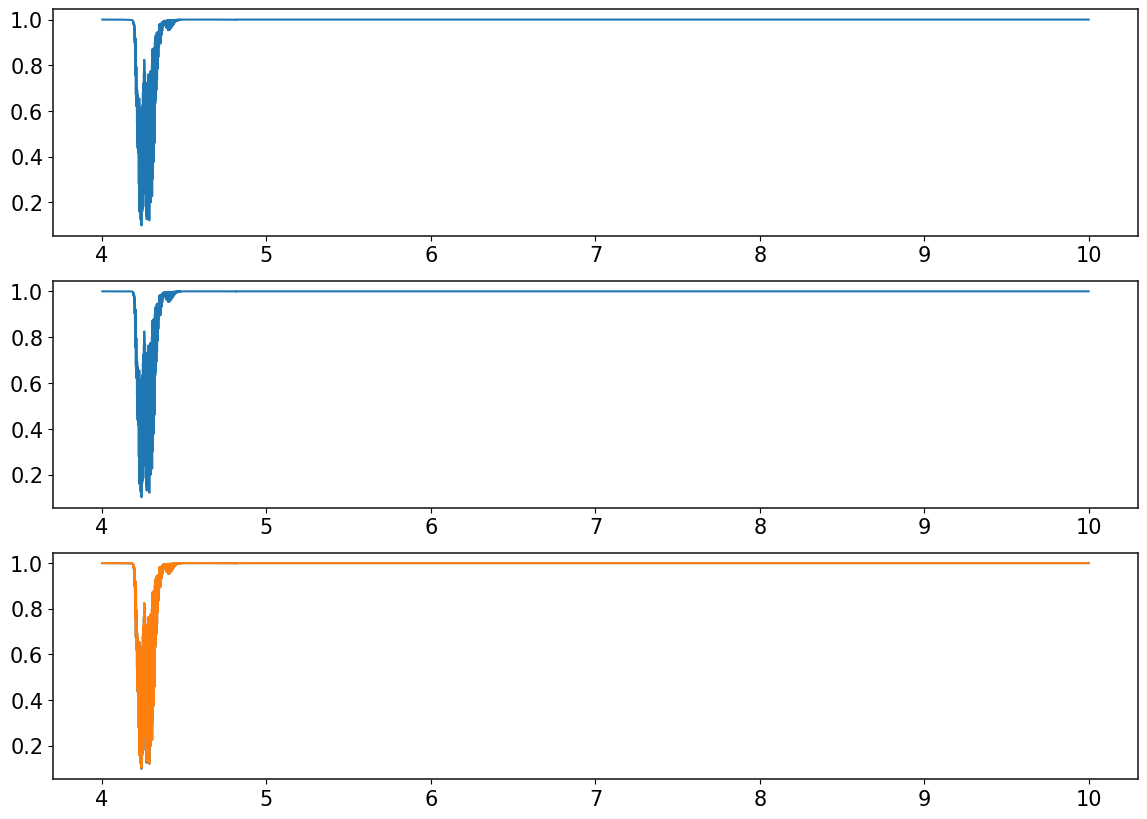

In [22]:
gt = np.load("SIMULATED/Transmittance_Standard_CO2_4-10_1m__downsampled_to_Simulated_Standard_CO2_4-10_1m.npy")
sim = np.load("SIMULATED/Simulated_Standard_CO2_4-10_1m.npy")  
plt.figure(figsize=(14, 10))
plt.subplot(311)
plt.plot(gt[0], gt[1])
plt.subplot(312)
plt.plot(sim[0], sim[1])
plt.subplot(313)
plt.plot(gt[0], gt[1])
plt.plot(sim[0], sim[1])

In [23]:
mae = np.mean(np.abs(gt[1]-sim[1]))
print("MAE:", mae)

MAE: 0.0001001012381807494


N2O

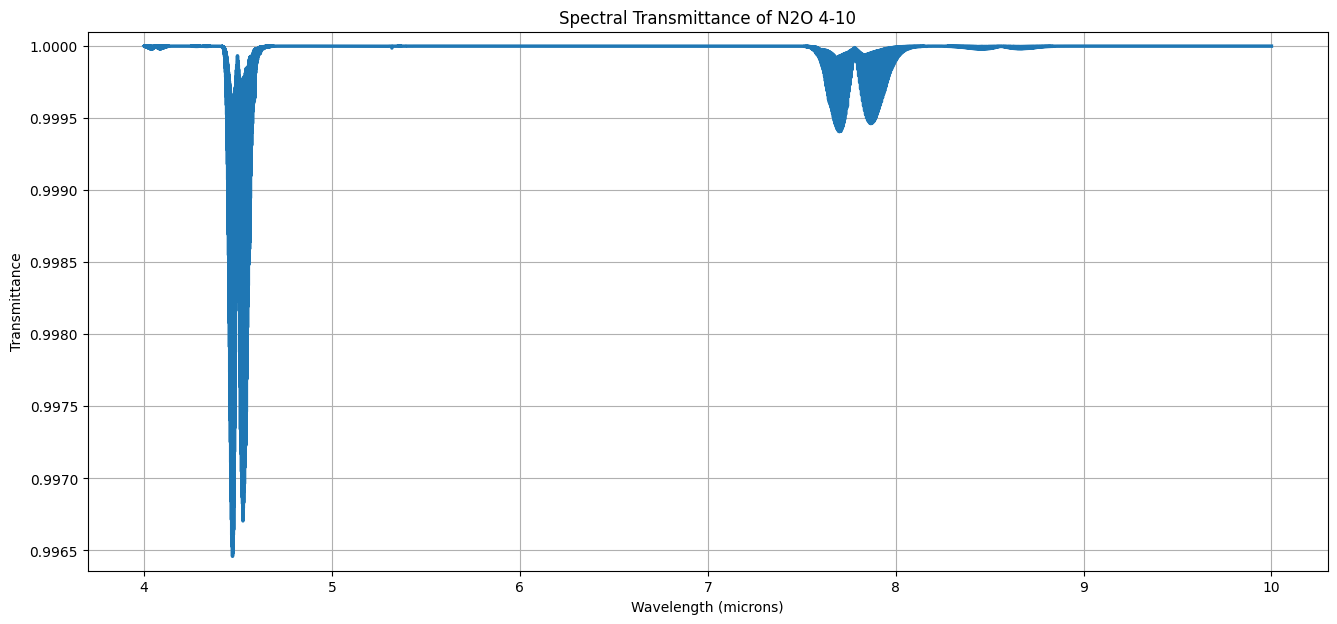

In [3]:
'''gt'''
wave, tr = np.load('GT_PROFE/N2O_4-10.npy')
name = 'N2O 4-10'
plot_npy(wave, tr, name=name)

In [4]:
Ptotal = convert_atm(1013, "mbar")
3.2e-07 * Ptotal

3.1992104613866274e-07

/teamspace/studios/this_studio/Stand-off
Using species: ['N2O']
DEBUG: N2O iso=1 qfile=TIPS/N2O/q21.txt exists=True
DEBUG: N2O iso=2 qfile=TIPS/N2O/q22.txt exists=True
DEBUG: N2O iso=3 qfile=TIPS/N2O/q23.txt exists=True
DEBUG: N2O iso=4 qfile=TIPS/N2O/q24.txt exists=True
DEBUG: N2O iso=5 qfile=TIPS/N2O/q25.txt exists=True


/teamspace/studios/this_studio/Stand-off/final_forward_attenuation.py:252: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(qfile, header=None, delim_whitespace=True, comment='#')
/teamspace/studios/this_studio/Stand-off/final_forward_attenuation.py:252: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(qfile, header=None, delim_whitespace=True, comment='#')
/teamspace/studios/this_studio/Stand-off/final_forward_attenuation.py:252: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(qfile, header=None, delim_whitespace=True, comment='#')
/teamspace/studios/this_studio/Stand-off/final_forward_attenuation.py:252: FutureWarning: The 'delim_whitespace' keyword in 

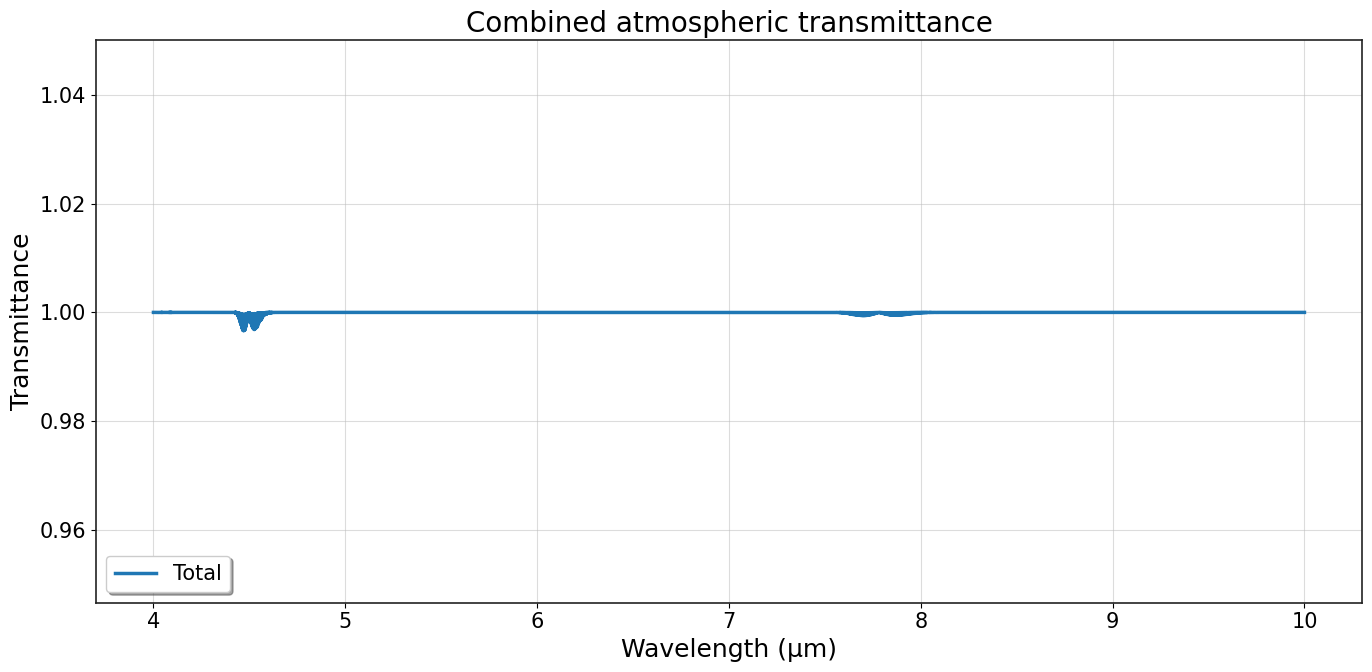

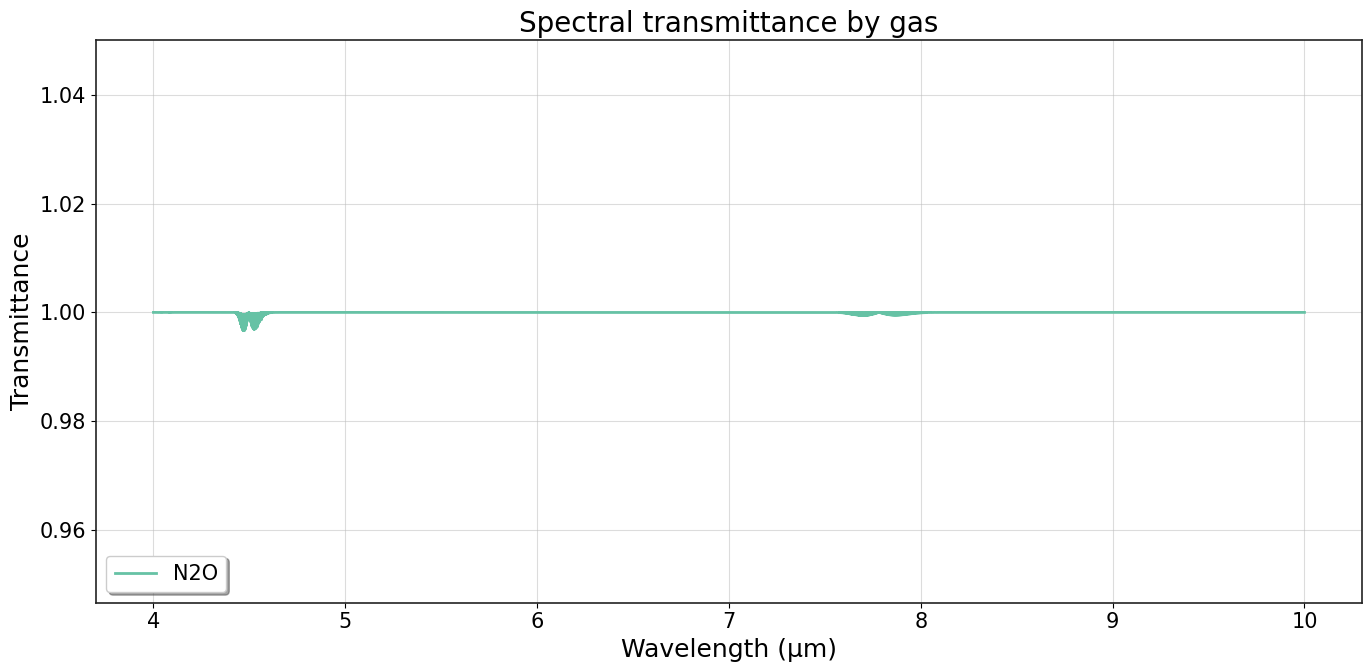

In [33]:
'''simulated'''
Ptotal = convert_atm(1013, "mbar")
T = 288.2

sp = default_species()
for s in sp:
     if s.name == 'N2O': s.Pmol = 3.1992104613866274e-07
     else: s.Pmol = 0.0
    

import os
print(os.getcwd())

res = run_simulation(
    species=sp,
    parfile='PARS/ALL.par',
    nu_min=1000, nu_max=2500, dnu=0.0001,
    tileW=20.0, guard=5.0,
    temp_K=T, L_m=1.0, pres=Ptotal,
    delta_um=0.0001,
    save_csv=True, outdir='OUT', make_plots=True, 
    att=False, transmission_npy_name='Simulated_N2O_4-10_1m.npy',
    use_all_isotopologues=True, species_to_use=['N2O']

)

lambda_um = res['lambda_centers']
Tprod = res['T_prod_samp']
Tco2  = res['T_each_samp'][0]

In [34]:
gt = np.load("GT_PROFE/N2O_4-10.npy")
sim = np.load("SIMULATED/Simulated_N2O_4-10_1m.npy")  
output = "SIMULATED/Transmittance_N2O_4-10_1m__downsampled_to_Simulated_N2O_4-10_1m.npy"
downsample(sim, gt, output)

In [40]:
sim = np.load("SIMULATED/Simulated_N2O_4-10_1m.npy")  
sim.shape

(2, 59999)

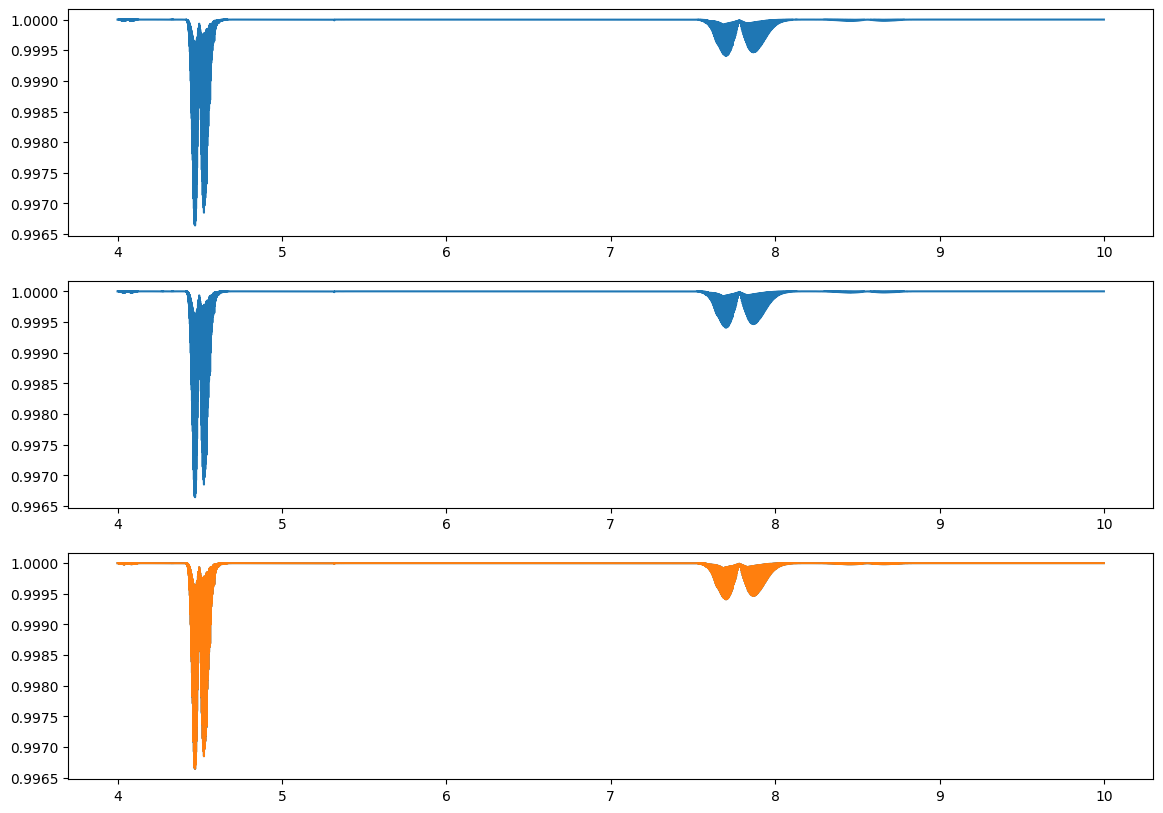

In [2]:
gt = np.load("SIMULATED/Transmittance_N2O_4-10_1m__downsampled_to_Simulated_N2O_4-10_1m.npy")
sim = np.load("SIMULATED/Simulated_N2O_4-10_1m.npy")  
plt.figure(figsize=(14, 10))
plt.subplot(311)
plt.plot(gt[0], gt[1])
plt.subplot(312)
plt.plot(sim[0], sim[1])
plt.subplot(313)
plt.plot(gt[0], gt[1])
plt.plot(sim[0], sim[1])

In [3]:
print(len(gt[0]))

59999


MAE: 1.2064351626804826e-07


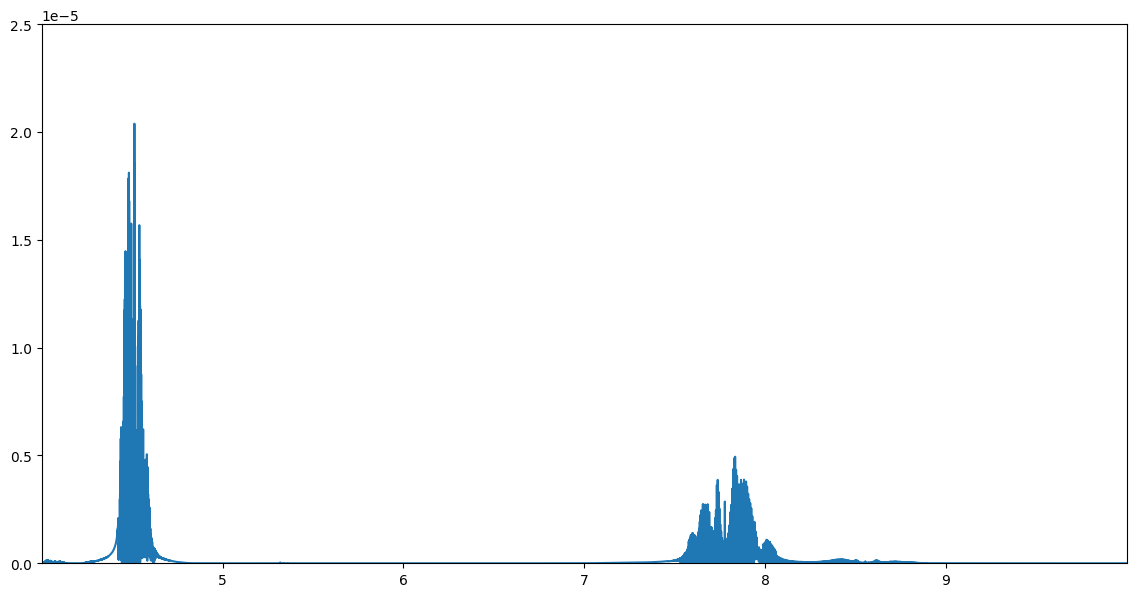

In [11]:
residual = np.abs((gt[1]-sim[1]))
mae = np.mean(np.abs(gt[1]-sim[1]))
plt.figure(figsize=(14,7))
plt.plot(gt[0], residual)
plt.axis([min(gt[0]), max(gt[0]), 0, 0.000025])
print("MAE:", mae)

CH4

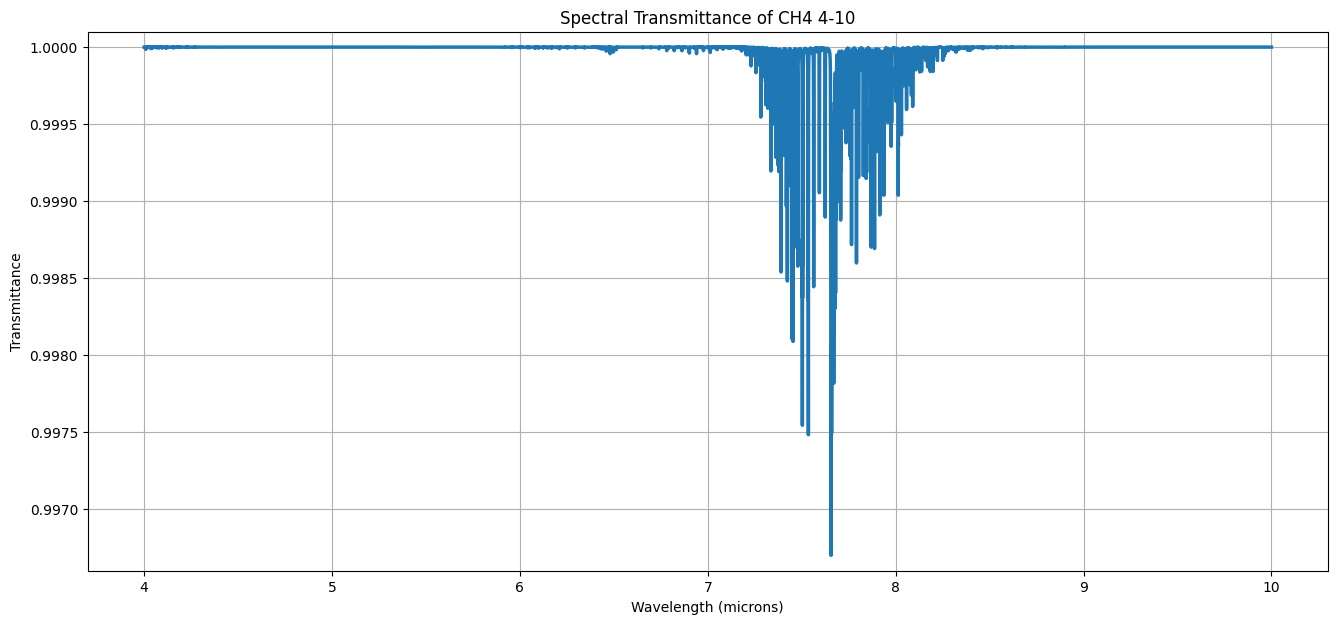

In [4]:
'''gt'''
wave, tr = np.load('GT_PROFE/CH4_4-10.npy')
name = 'CH4 4-10'
plot_npy(wave, tr, name=name)

/teamspace/studios/this_studio/Stand-off
Using species: ['CH4']
DEBUG: CH4 iso=1 qfile=TIPS/CH4/q32.txt exists=True
DEBUG: CH4 iso=2 qfile=TIPS/CH4/q33.txt exists=True
DEBUG: CH4 iso=3 qfile=TIPS/CH4/q34.txt exists=True
DEBUG: CH4 iso=4 qfile=TIPS/CH4/q35.txt exists=True


/teamspace/studios/this_studio/Stand-off/final_forward_attenuation.py:252: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(qfile, header=None, delim_whitespace=True, comment='#')
/teamspace/studios/this_studio/Stand-off/final_forward_attenuation.py:252: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(qfile, header=None, delim_whitespace=True, comment='#')
/teamspace/studios/this_studio/Stand-off/final_forward_attenuation.py:252: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(qfile, header=None, delim_whitespace=True, comment='#')
/teamspace/studios/this_studio/Stand-off/final_forward_attenuation.py:252: FutureWarning: The 'delim_whitespace' keyword in 

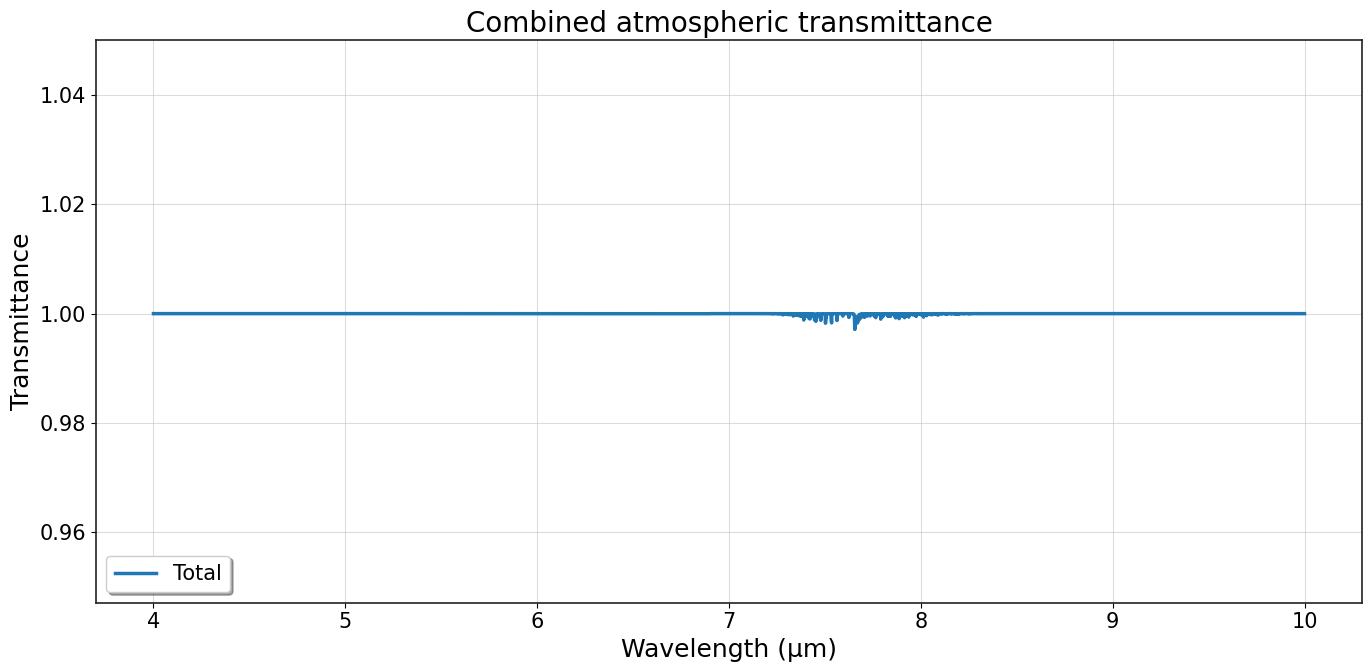

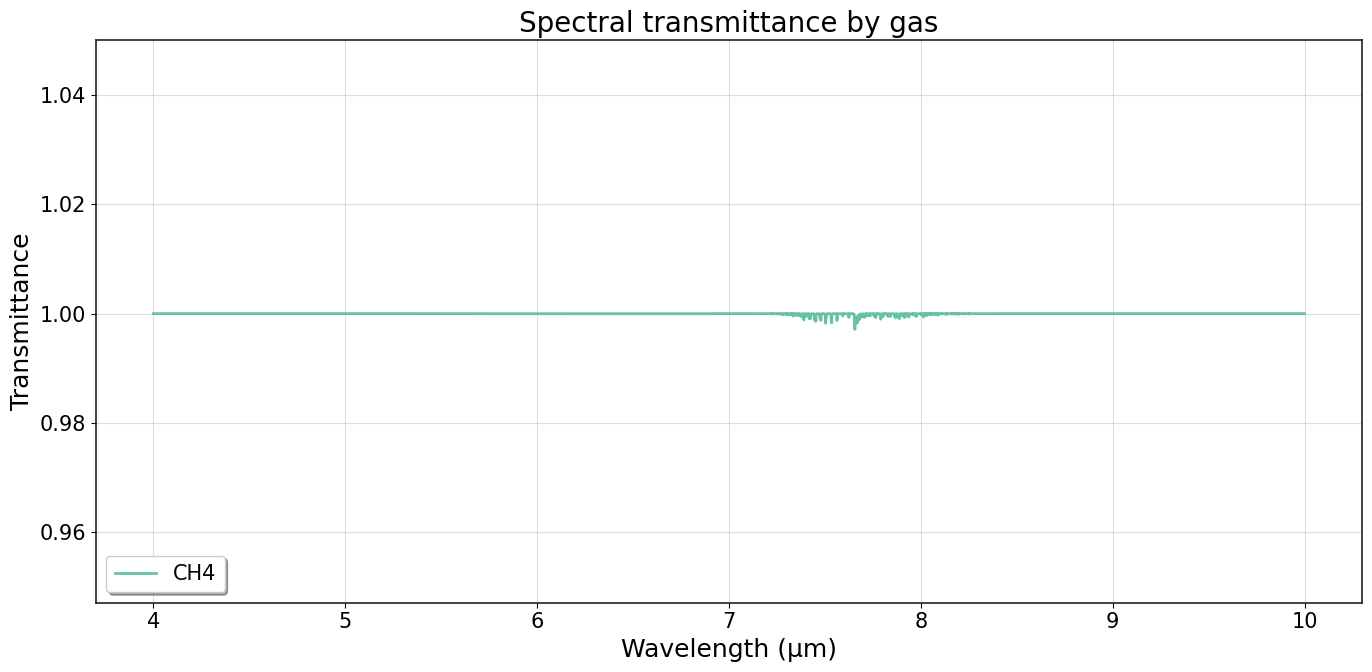

In [3]:
'''simulated'''
Ptotal = convert_atm(1013, "mbar")
T = 288.2
PCH4 = Ptotal * 1.7e-06 
sp = default_species()
for s in sp:
     if s.name == 'CH4': s.Pmol = PCH4
     else: s.Pmol = 0.0
    

import os
print(os.getcwd())

res = run_simulation(
    species=sp,
    parfile='PARS/ALL.par',
    nu_min=1000, nu_max=2500, dnu=0.001,
    tileW=20.0, guard=5.0,
    temp_K=T, L_m=1.0, pres=Ptotal,
    delta_um=0.001,
    save_csv=True, outdir='OUT', make_plots=True, 
    att=False, transmission_npy_name='Simulated_CH4_4-10_1m.npy',
    use_all_isotopologues=True, species_to_use=['CH4']

)

lambda_um = res['lambda_centers']
Tprod = res['T_prod_samp']
Tco2  = res['T_each_samp'][0]

In [4]:
gt = np.load('GT_PROFE/CH4_4-10.npy')
sim = np.load("SIMULATED/Simulated_CH4_4-10_1m.npy")  
output = "SIMULATED/Transmittance_CH4_4-10_1m__downsampled_to_Simulated_CH4_4-10_1m.npy"
downsample(sim, gt, output)

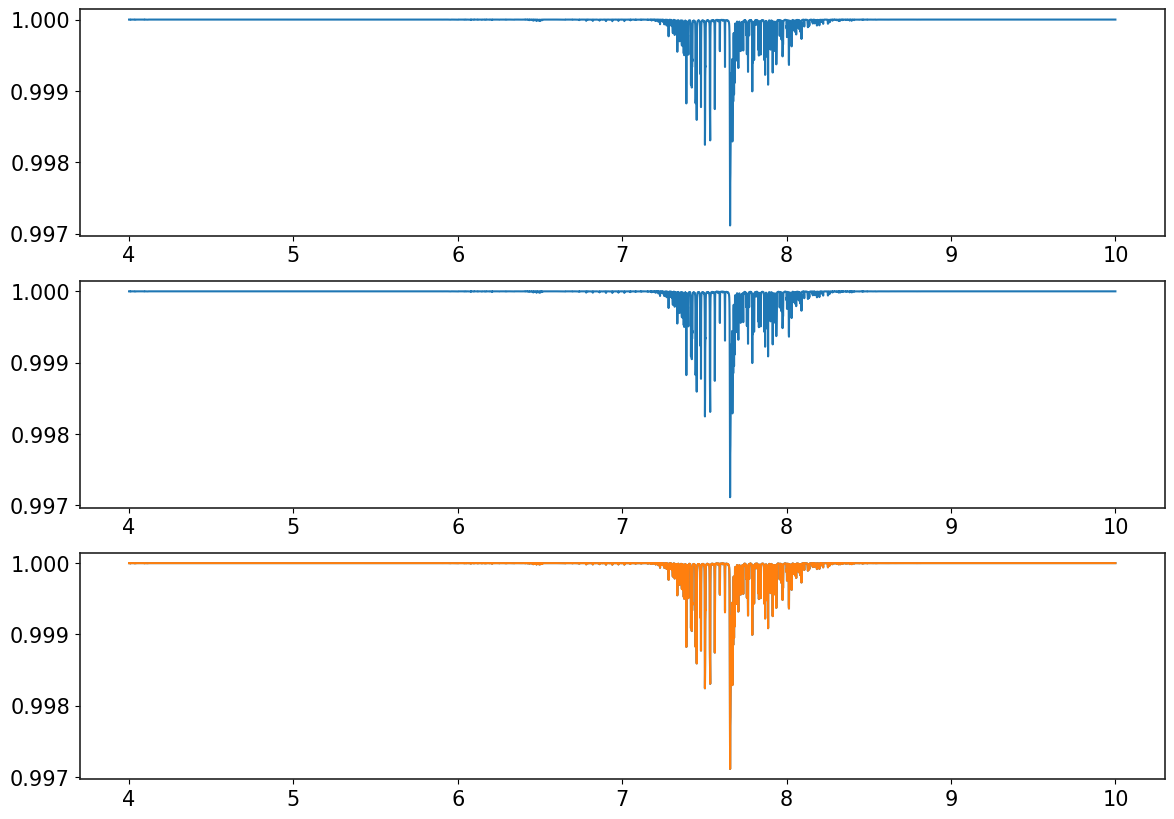

In [5]:
gt = np.load("SIMULATED/Transmittance_CH4_4-10_1m__downsampled_to_Simulated_CH4_4-10_1m.npy")
sim = np.load("SIMULATED/Simulated_CH4_4-10_1m.npy")  
plt.figure(figsize=(14, 10))
plt.subplot(311)
plt.plot(gt[0], gt[1])
plt.subplot(312)
plt.plot(sim[0], sim[1])
plt.subplot(313)
plt.plot(gt[0], gt[1])
plt.plot(sim[0], sim[1])

MAE: 7.621951138596192e-08


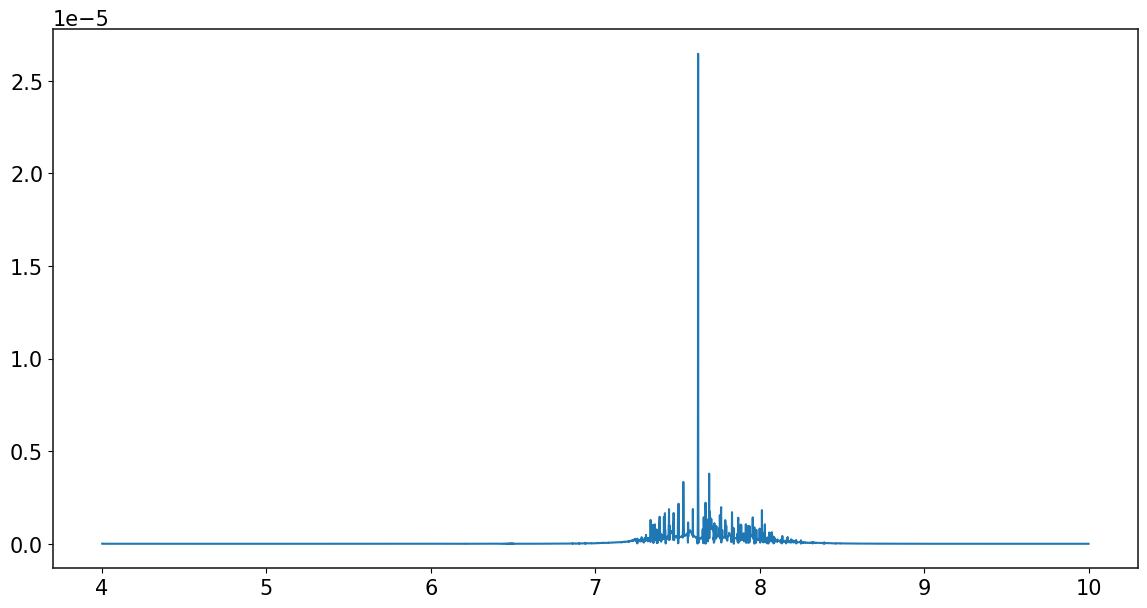

In [6]:
residual = np.abs((gt[1]-sim[1]))
mae = np.mean(np.abs(gt[1]-sim[1]))
plt.figure(figsize=(14,7))
plt.plot(gt[0], residual)
print("MAE:", mae)

CO

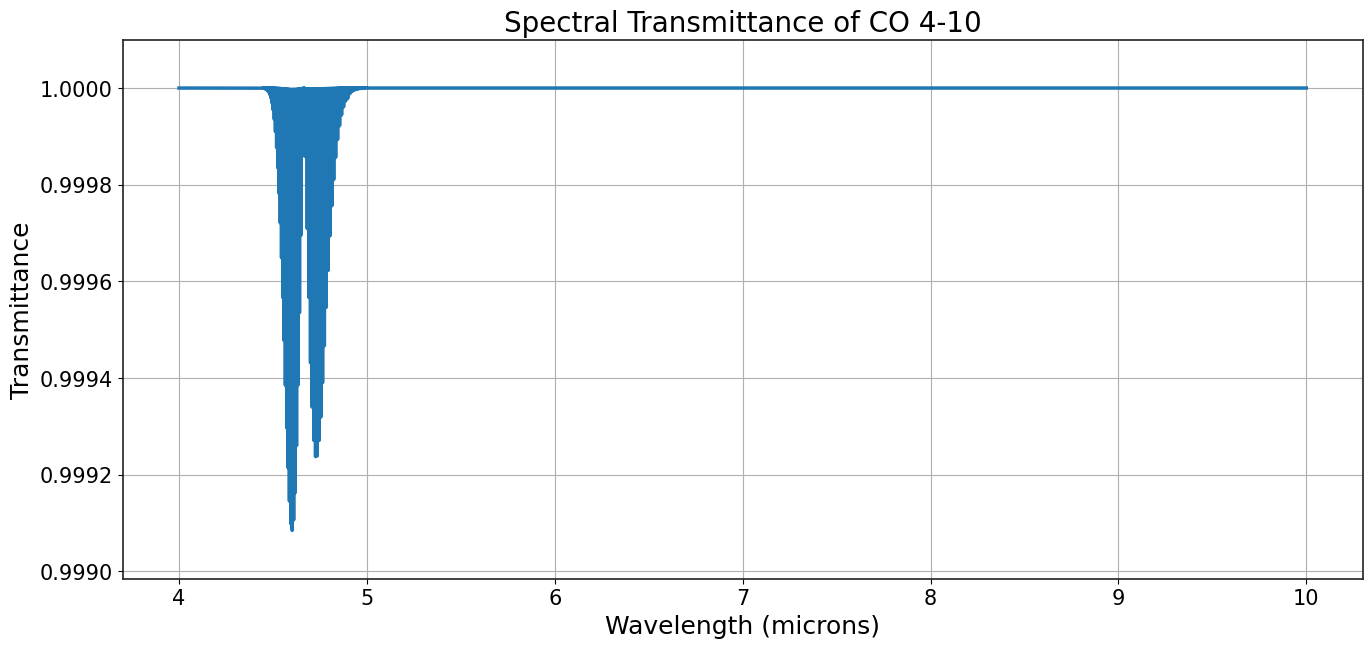

In [9]:
'''gt'''
wave, tr = np.load('GT_PROFE/CO_4-10.npy')
name = 'CO 4-10'
plot_npy(wave, tr, name=name)

/teamspace/studios/this_studio/Stand-off
Using species: ['CO']
DEBUG: CO iso=1 qfile=TIPS/CO/q26.txt exists=True
DEBUG: CO iso=2 qfile=TIPS/CO/q27.txt exists=True
DEBUG: CO iso=3 qfile=TIPS/CO/q28.txt exists=True
DEBUG: CO iso=4 qfile=TIPS/CO/q29.txt exists=True
DEBUG: CO iso=5 qfile=TIPS/CO/q30.txt exists=True
DEBUG: CO iso=6 qfile=TIPS/CO/q31.txt exists=True


/teamspace/studios/this_studio/Stand-off/final_forward_attenuation.py:252: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(qfile, header=None, delim_whitespace=True, comment='#')
/teamspace/studios/this_studio/Stand-off/final_forward_attenuation.py:252: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(qfile, header=None, delim_whitespace=True, comment='#')
/teamspace/studios/this_studio/Stand-off/final_forward_attenuation.py:252: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(qfile, header=None, delim_whitespace=True, comment='#')
/teamspace/studios/this_studio/Stand-off/final_forward_attenuation.py:252: FutureWarning: The 'delim_whitespace' keyword in 

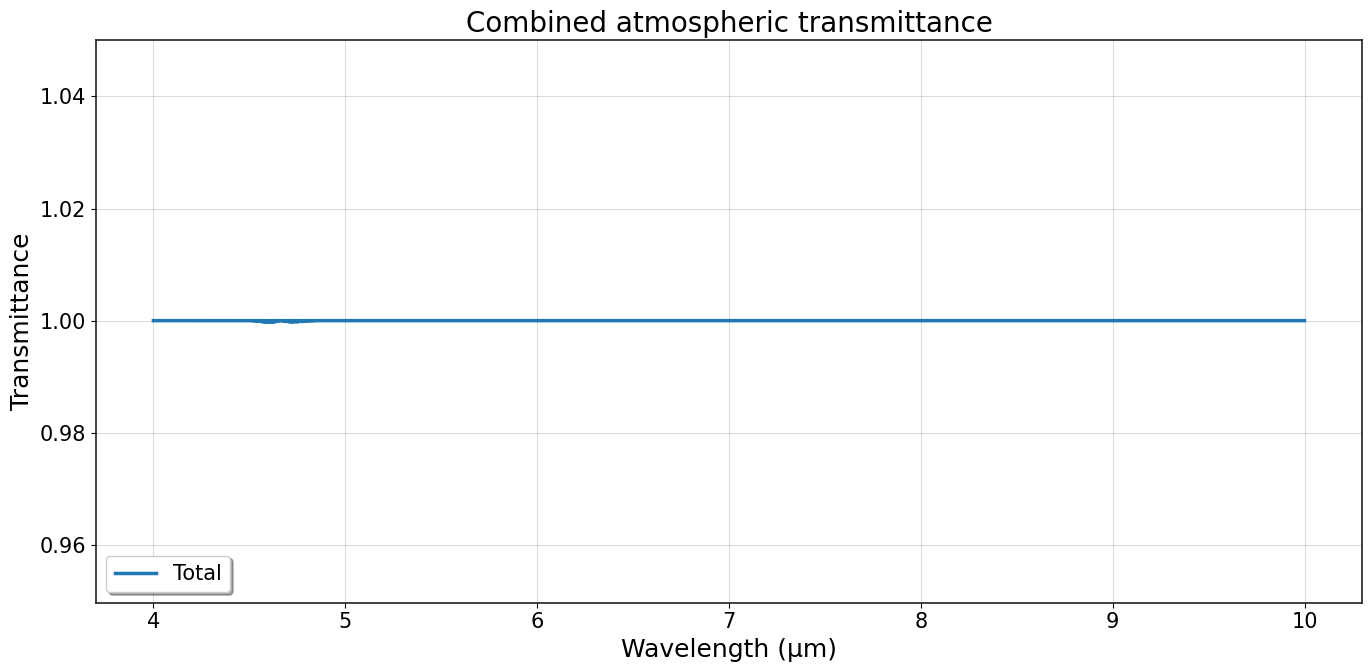

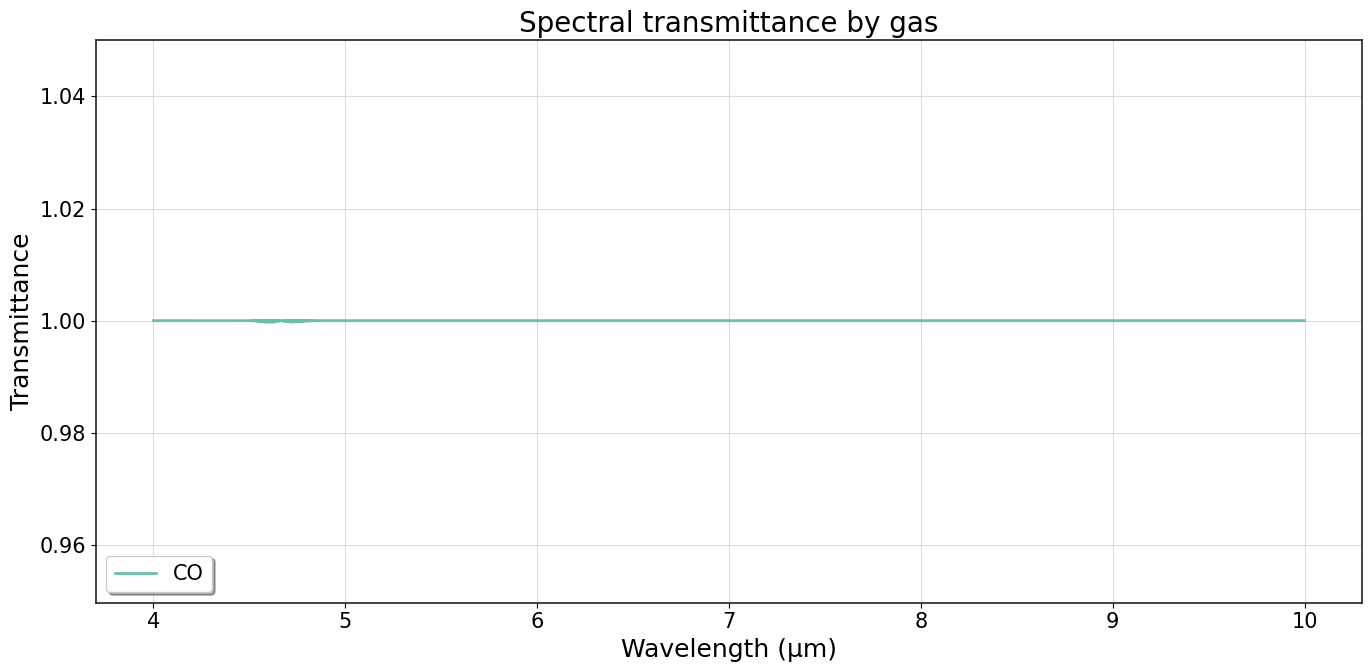

In [10]:
'''simulated'''
Ptotal = convert_atm(1013, "mbar")
T = 288.2
PCO = Ptotal * 1.5e-07  
sp = default_species()
for s in sp:
     if s.name == 'CO': s.Pmol = PCO
     else: s.Pmol = 0.0
    

import os
print(os.getcwd())

res = run_simulation(
    species=sp,
    parfile='PARS/ALL.par',
    nu_min=1000, nu_max=2500, dnu=0.001,
    tileW=20.0, guard=5.0,
    temp_K=T, L_m=1.0, pres=Ptotal,
    delta_um=0.001,
    save_csv=True, outdir='OUT', make_plots=True, 
    att=False, transmission_npy_name='Simulated_CO_4-10_1m.npy',
    use_all_isotopologues=True, species_to_use=['CO']

)

lambda_um = res['lambda_centers']
Tprod = res['T_prod_samp']
Tco2  = res['T_each_samp'][0]

In [11]:
gt = np.load('GT_PROFE/CO_4-10.npy')
sim = np.load("SIMULATED/Simulated_CO_4-10_1m.npy")  
output = "SIMULATED/Transmittance_CO_4-10_1m__downsampled_to_Simulated_CO_4-10_1m.npy"
downsample(sim, gt, output)

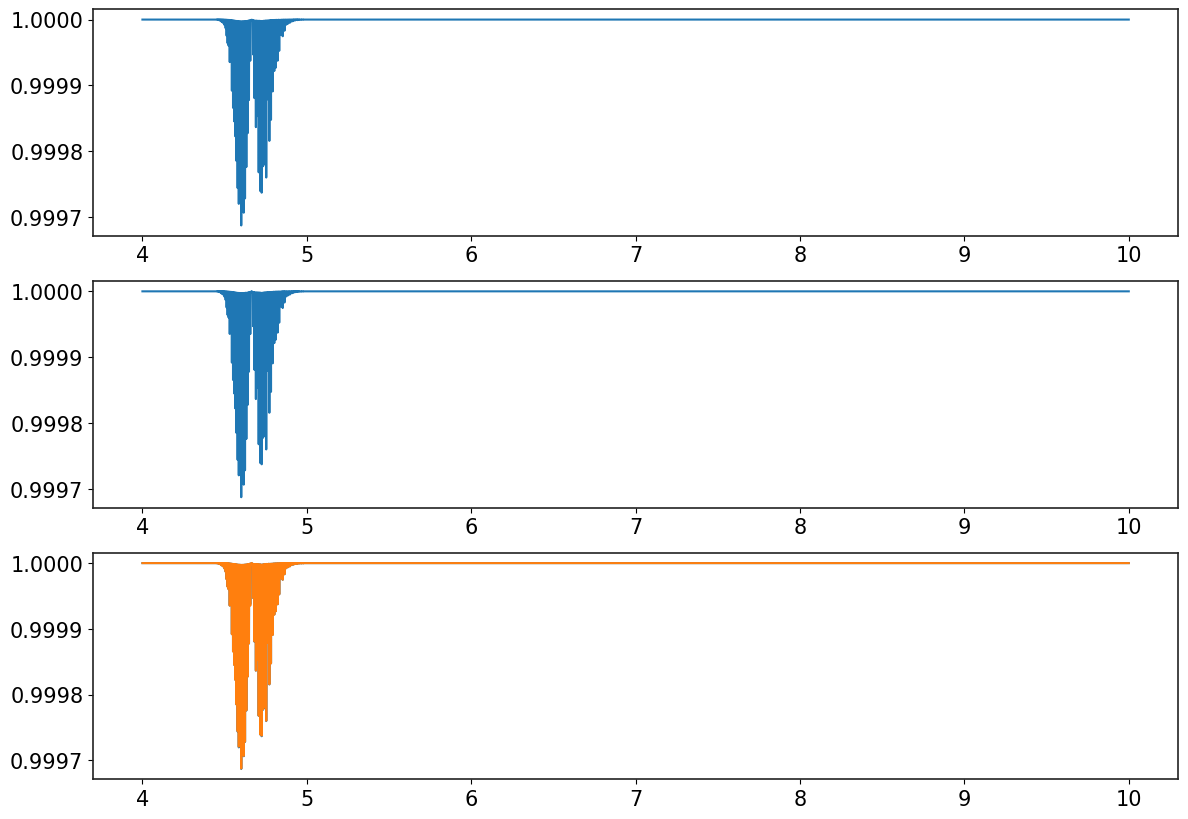

In [12]:
gt = np.load("SIMULATED/Transmittance_CO_4-10_1m__downsampled_to_Simulated_CO_4-10_1m.npy")
sim = np.load("SIMULATED/Simulated_CO_4-10_1m.npy")  
plt.figure(figsize=(14, 10))
plt.subplot(311)
plt.plot(gt[0], gt[1])
plt.subplot(312)
plt.plot(sim[0], sim[1])
plt.subplot(313)
plt.plot(gt[0], gt[1])
plt.plot(sim[0], sim[1])

MAE: 5.932689351045875e-09


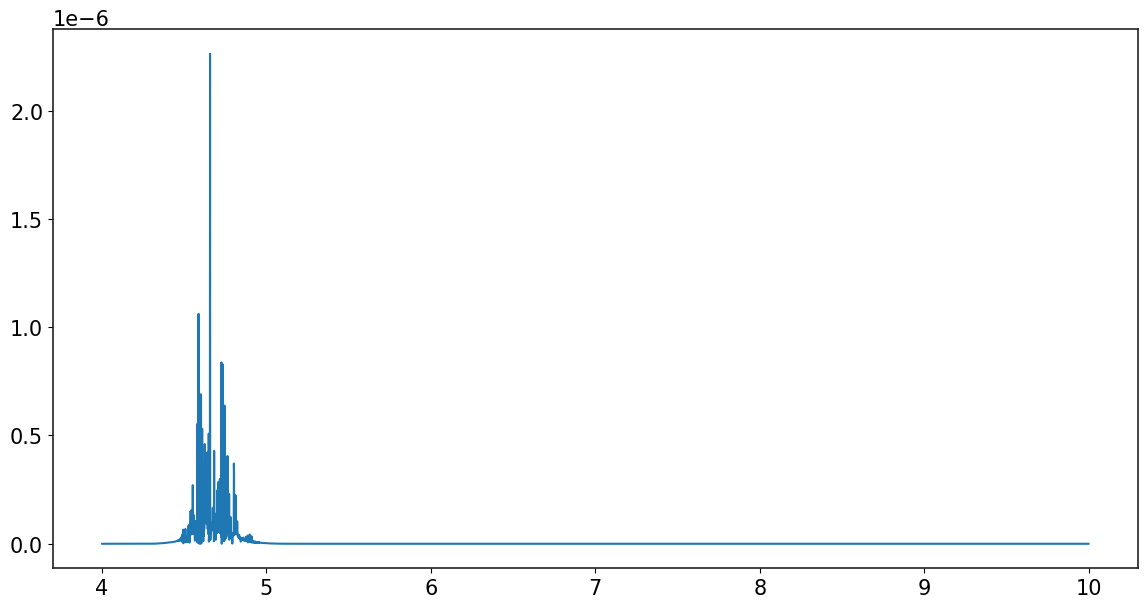

In [13]:
residual = np.abs((gt[1]-sim[1]))
mae = np.mean(np.abs(gt[1]-sim[1]))
plt.figure(figsize=(14,7))
plt.plot(gt[0], residual)
print("MAE:", mae)

O3

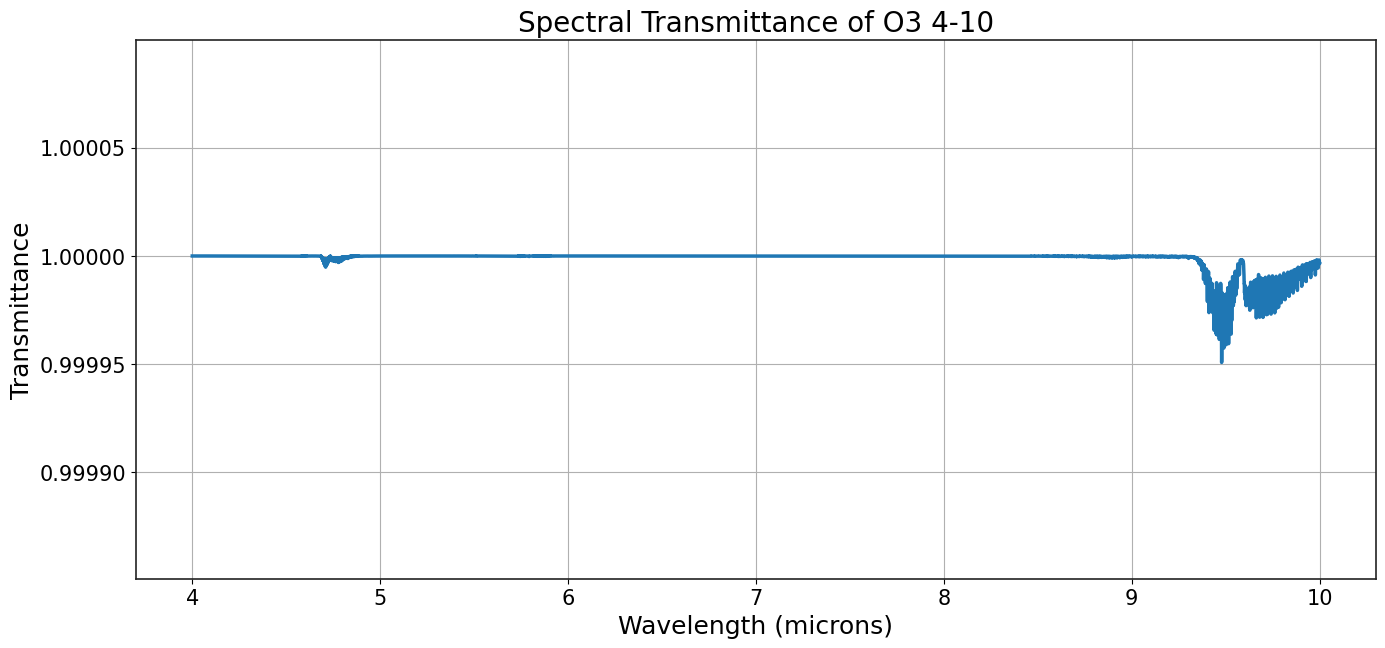

In [14]:
'''gt'''
wave, tr = np.load('GT_PROFE/O3_4-10um_1m.npy')
name = 'O3 4-10'
plot_npy(wave, tr, name=name)

/teamspace/studios/this_studio/Stand-off
Using species: ['O3']
DEBUG: O3 iso=1 qfile=TIPS/O3/q16.txt exists=True
DEBUG: O3 iso=2 qfile=TIPS/O3/q17.txt exists=True
DEBUG: O3 iso=3 qfile=TIPS/O3/q18.txt exists=True
DEBUG: O3 iso=4 qfile=TIPS/O3/q19.txt exists=True
DEBUG: O3 iso=5 qfile=TIPS/O3/q20.txt exists=True


/teamspace/studios/this_studio/Stand-off/final_forward_attenuation.py:252: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(qfile, header=None, delim_whitespace=True, comment='#')
/teamspace/studios/this_studio/Stand-off/final_forward_attenuation.py:252: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(qfile, header=None, delim_whitespace=True, comment='#')
/teamspace/studios/this_studio/Stand-off/final_forward_attenuation.py:252: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(qfile, header=None, delim_whitespace=True, comment='#')
/teamspace/studios/this_studio/Stand-off/final_forward_attenuation.py:252: FutureWarning: The 'delim_whitespace' keyword in 

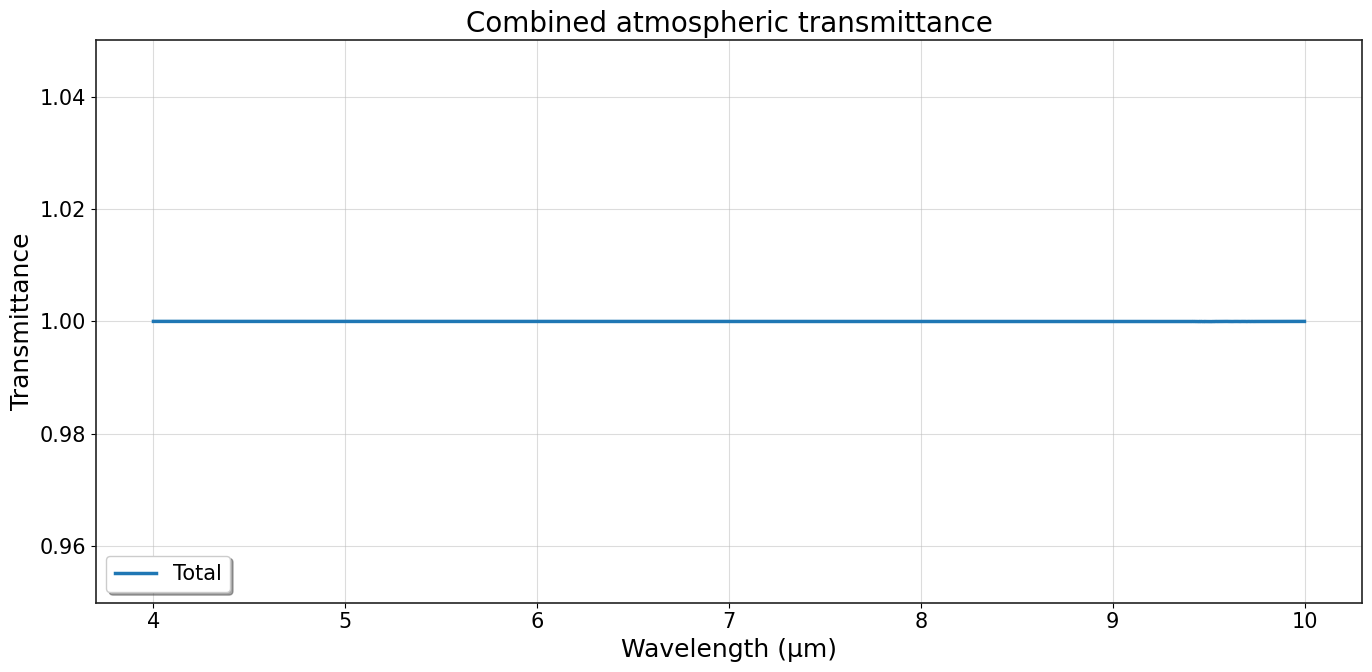

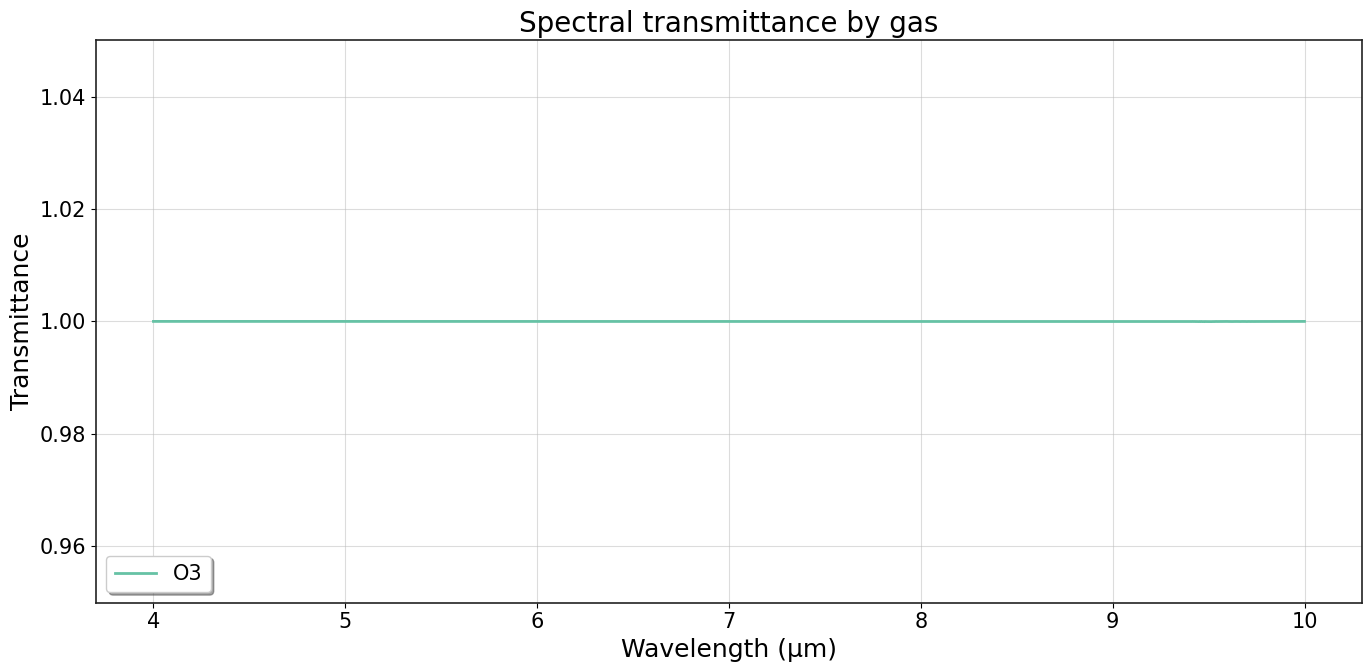

In [15]:
'''simulated'''
Ptotal = convert_atm(1013, "mbar")
T = 288.2
PO3 = Ptotal * 2.66e-08  
sp = default_species()
for s in sp:
     if s.name == 'O3': s.Pmol = PO3
     else: s.Pmol = 0.0
    

import os
print(os.getcwd())

res = run_simulation(
    species=sp,
    parfile='PARS/ALL.par',
    nu_min=1000, nu_max=2500, dnu=0.001,
    tileW=20.0, guard=5.0,
    temp_K=T, L_m=1.0, pres=Ptotal,
    delta_um=0.001,
    save_csv=True, outdir='OUT', make_plots=True, 
    att=False, transmission_npy_name='Simulated_O3_4-10_1m.npy',
    use_all_isotopologues=True, species_to_use=['O3']

)

lambda_um = res['lambda_centers']
Tprod = res['T_prod_samp']
Tco2  = res['T_each_samp'][0]

In [16]:
gt = np.load('GT_PROFE/O3_4-10um_1m.npy')
sim = np.load("SIMULATED/Simulated_O3_4-10_1m.npy")  
output = "SIMULATED/Transmittance_O3_4-10_1m__downsampled_to_Simulated_O3_4-10_1m.npy"
downsample(sim, gt, output)

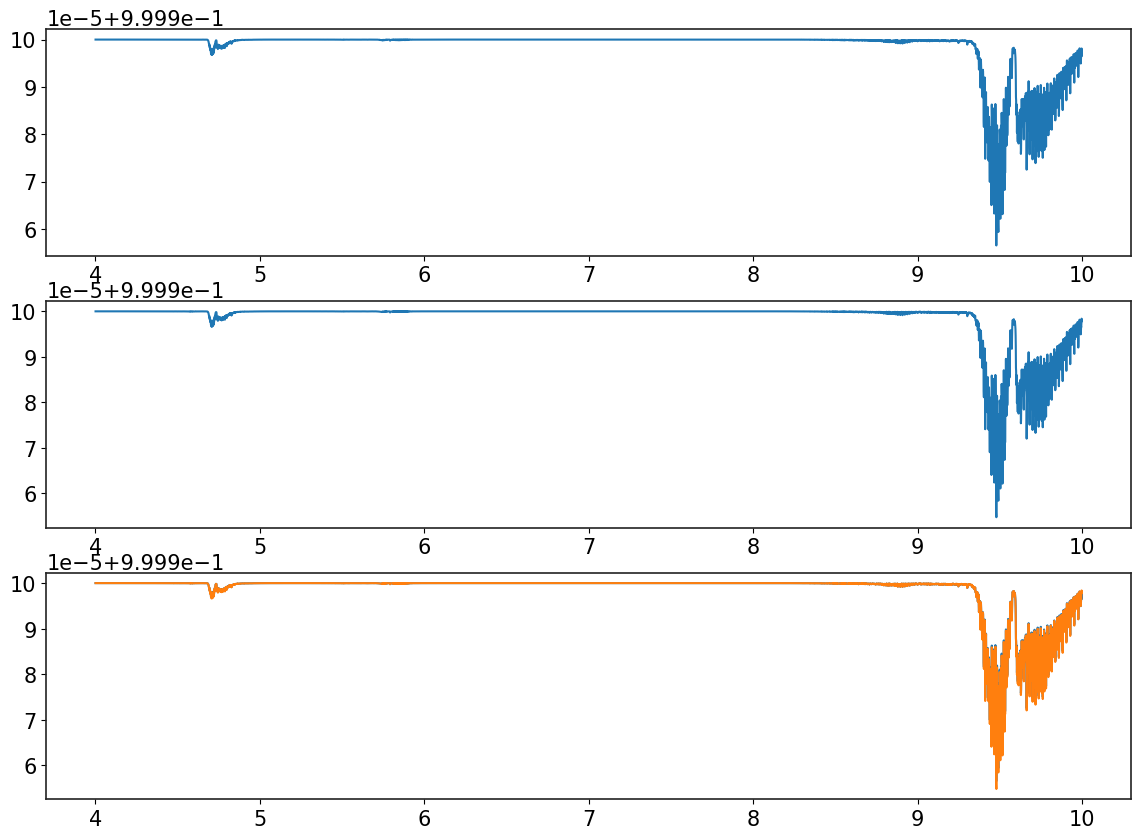

In [17]:
gt = np.load("SIMULATED/Transmittance_O3_4-10_1m__downsampled_to_Simulated_O3_4-10_1m.npy")
sim = np.load("SIMULATED/Simulated_O3_4-10_1m.npy")  
plt.figure(figsize=(14, 10))
plt.subplot(311)
plt.plot(gt[0], gt[1])
plt.subplot(312)
plt.plot(sim[0], sim[1])
plt.subplot(313)
plt.plot(gt[0], gt[1])
plt.plot(sim[0], sim[1])

MAE: 3.338301916613614e-08


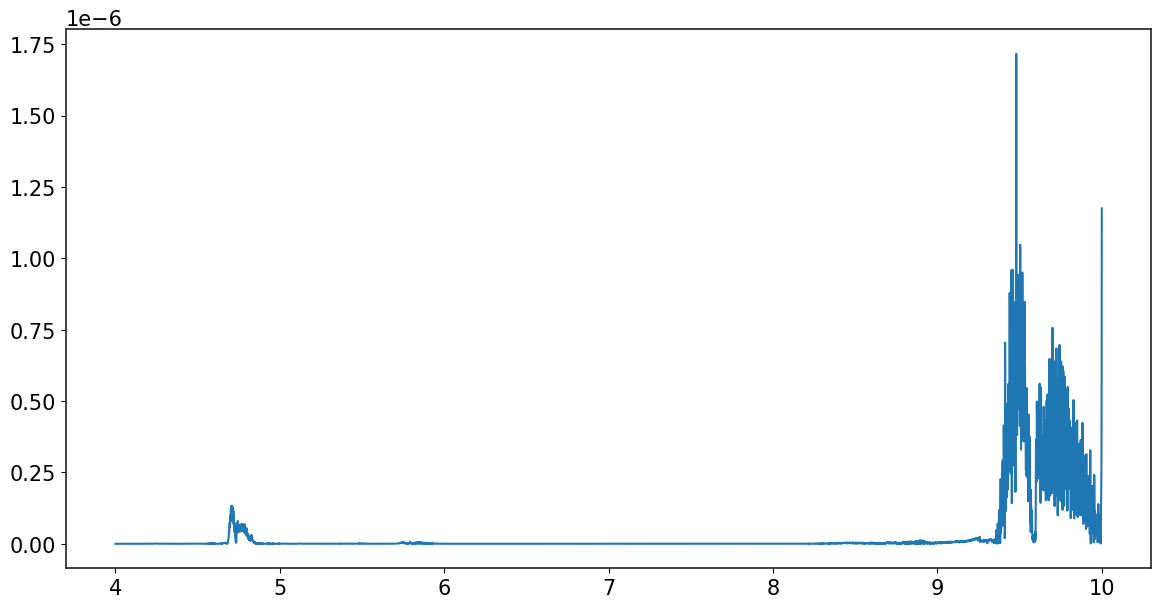

In [18]:
residual = np.abs((gt[1]-sim[1]))
mae = np.mean(np.abs(gt[1]-sim[1]))
plt.figure(figsize=(14,7))
plt.plot(gt[0], residual)
print("MAE:", mae)